# COVID-19 X-Ray Detection — Custom CNN

This notebook trains a custom CNN to classify chest X-rays into 4 categories:
- COVID
- Normal
- Lung Opacity
- Viral Pneumonia

Dataset: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database

In [15]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import requests
from PIL import Image
from io import BytesIO
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

from tqdm import tqdm

SEED = 102
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


In [2]:
# Download via Kaggle API (requires ~/.kaggle/kaggle.json)
# !kaggle datasets download -d tawsifurrahman/covid19-radiography-database --unzip -p ./data

DATA_DIR = Path('/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset')

CLASS_NAMES = ['COVID', 'Normal', 'Lung_Opacity', 'Viral Pneumonia']
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

# Count images per class
for cls in CLASS_NAMES:
    path = DATA_DIR / cls / 'images'
    count = len(list(path.glob('*.png'))) if path.exists() else 0
    print(f'{cls}: {count} images')

COVID: 3616 images
Normal: 10192 images
Lung_Opacity: 6012 images
Viral Pneumonia: 1345 images


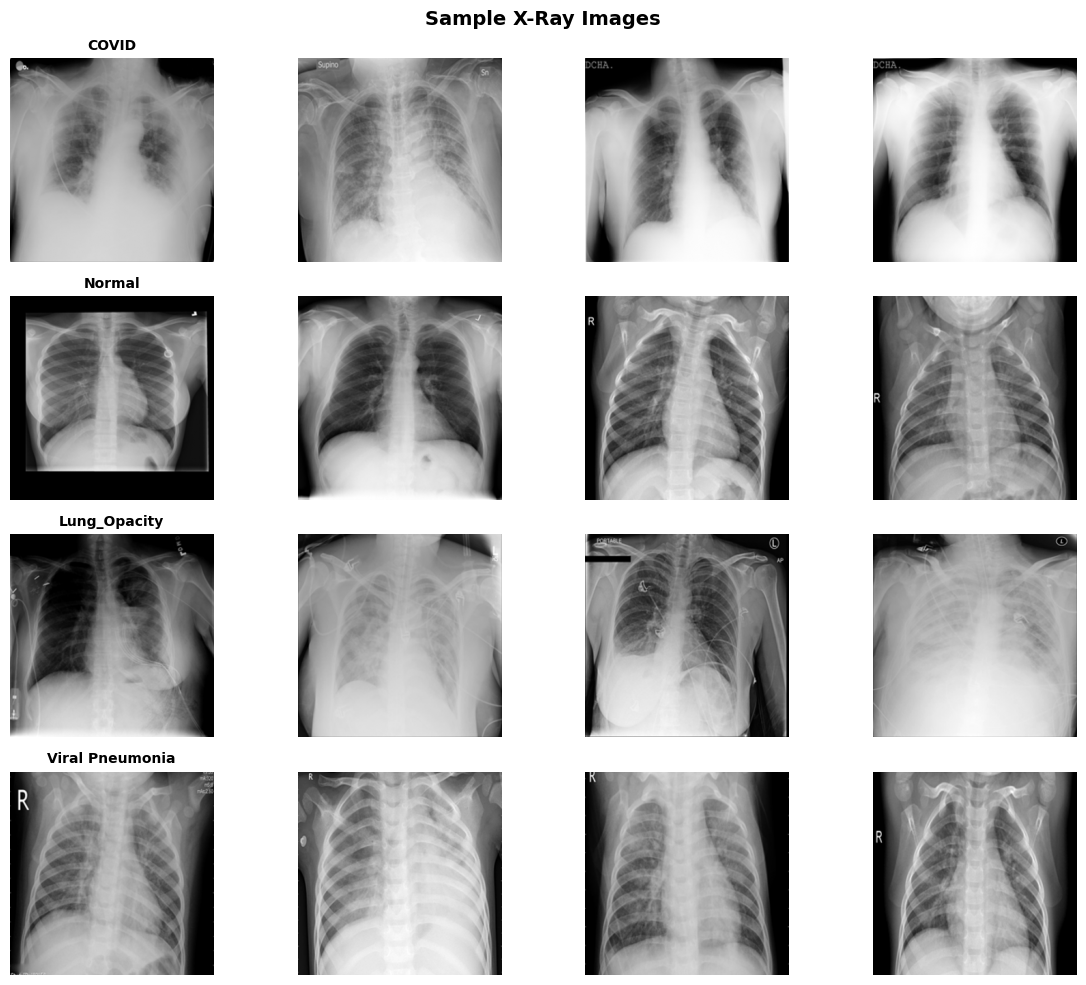

In [3]:
fig, axes = plt.subplots(len(CLASS_NAMES), 4, figsize=(12, 10))

for row, cls in enumerate(CLASS_NAMES):
    img_dir = DATA_DIR / cls / 'images'
    samples = sorted(img_dir.glob('*.png'))[:4]
    for col, img_path in enumerate(samples):
        ax = axes[row][col]
        ax.imshow(Image.open(img_path).convert('L'), cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_title(cls, fontsize=10, fontweight='bold')

plt.suptitle('Sample X-Ray Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
class XRayDataset(Dataset):
    def __init__(self, file_list, transform=None):
        # file_list is a list of (image_path, label) tuples
        self.file_list = file_list
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path, label = self.file_list[idx]
        # Convert to RGB so shape is always (3, H, W)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


def build_file_list(data_dir, class_to_idx):
    """Return a shuffled list of (path, label) for all classes."""
    file_list = []
    for cls_name, label in class_to_idx.items():
        img_dir = Path(data_dir) / cls_name / 'images'
        for img_path in img_dir.glob('*.png'):
            file_list.append((str(img_path), label))
    random.shuffle(file_list)
    return file_list


def split_data(file_list, train_ratio=0.70, val_ratio=0.15):
    """Stratified split into train / val / test."""
    from collections import defaultdict
    by_class = defaultdict(list)
    for item in file_list:
        by_class[item[1]].append(item)

    train, val, test = [], [], []
    for label, items in by_class.items():
        n  = len(items)
        t1 = int(n * train_ratio)
        t2 = int(n * (train_ratio + val_ratio))
        train += items[:t1]
        val   += items[t1:t2]
        test  += items[t2:]
    return train, val, test


# Config
IMG_SIZE   = 128   # smaller size = faster training
BATCH_SIZE = 32
NUM_EPOCHS = 20
LR         = 1e-3

# Transforms

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


all_files = build_file_list(DATA_DIR, CLASS_TO_IDX)
train_files, val_files, test_files = split_data(all_files)

print(f'Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}')

# DataLoaders
train_loader = DataLoader(XRayDataset(train_files, train_transform),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(XRayDataset(val_files,   eval_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(XRayDataset(test_files,  eval_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Train: 14814 | Val: 3175 | Test: 3176


In [5]:
class ConvBlock(nn.Module):
    """A single conv block: Conv2d -> BatchNorm -> ReLU -> MaxPool."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)  # halves spatial size
        )

    def forward(self, x):
        return self.block(x)


class CustomCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        # Feature extractor — 4 conv blocks
        # Input:  (B, 3, 128, 128)
        # After block1: (B, 32,  64, 64)
        # After block2: (B, 64,  32, 32)
        # After block3: (B, 128, 16, 16)
        # After block4: (B, 256,  8,  8)
        self.features = nn.Sequential(
            ConvBlock(3,   32),
            ConvBlock(32,  64),
            ConvBlock(64,  128),
            ConvBlock(128, 256),
        )

        # Global average pooling: (B, 256, 8, 8) -> (B, 256)
        
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).flatten(1)  # flatten all dims except batch
        x = self.classifier(x)
        return x


model = CustomCNN(num_classes=4).to(DEVICE)

# Sanity check
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
print('Output shape:', model(dummy).shape)  # expect [2, 4]

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Output shape: torch.Size([2, 4])
Total parameters: 1,240,036


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# Reduce LR by half if val loss stops improving for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)


def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out  = model(imgs)
        loss = criterion(out, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = out.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


# Training loop
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0
best_weights = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc          = train_epoch(model, train_loader)
    val_loss,   val_acc, _, _      = eval_epoch(model, val_loader)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    
    flag = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = model.state_dict().copy()
        torch.save(best_weights, 'best_model.pt')
        flag = '<-- best'

    print(f'Epoch {epoch:3d}/{NUM_EPOCHS}  '
          f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  '
          f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}  {flag}')

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Epoch   1/20  Train Loss: 0.8861  Train Acc: 0.6401  Val Loss: 0.7930  Val Acc: 0.6948  <-- best
Epoch   2/20  Train Loss: 0.6797  Train Acc: 0.7342  Val Loss: 0.8010  Val Acc: 0.7235  <-- best
Epoch   3/20  Train Loss: 0.5478  Train Acc: 0.7927  Val Loss: 0.5314  Val Acc: 0.8003  <-- best
Epoch   4/20  Train Loss: 0.4620  Train Acc: 0.8308  Val Loss: 0.4314  Val Acc: 0.8353  <-- best
Epoch   5/20  Train Loss: 0.4113  Train Acc: 0.8516  Val Loss: 0.4009  Val Acc: 0.8532  <-- best
Epoch   6/20  Train Loss: 0.3779  Train Acc: 0.8630  Val Loss: 0.9437  Val Acc: 0.7427  
Epoch   7/20  Train Loss: 0.3558  Train Acc: 0.8713  Val Loss: 0.3687  Val Acc: 0.8573  <-- best
Epoch   8/20  Train Loss: 0.3390  Train Acc: 0.8788  Val Loss: 0.3595  Val Acc: 0.8693  <-- best
Epoch   9/20  Train Loss: 0.3210  Train Acc: 0.8834  Val Loss: 0.3005  Val Acc: 0.8863  <-- best
Epoch  10/20  Train Loss: 0.3004  Train Acc: 0.8933  Val Loss: 0.3033  Val Acc: 0.8951  <-- best
Epoch  11/20  Train Loss: 0.2984  Trai

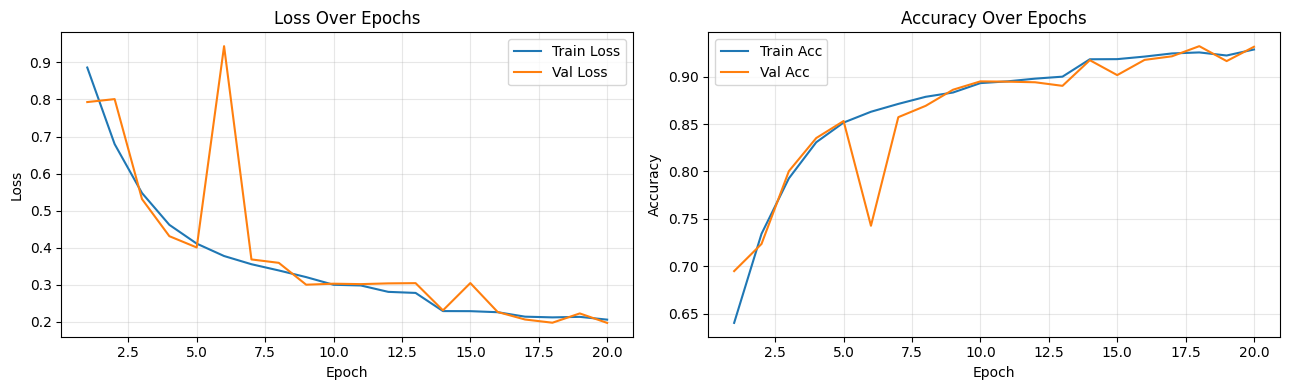

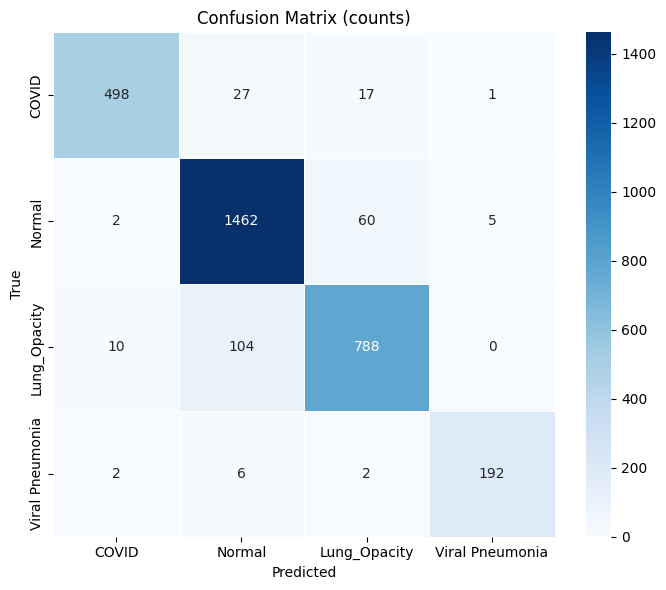

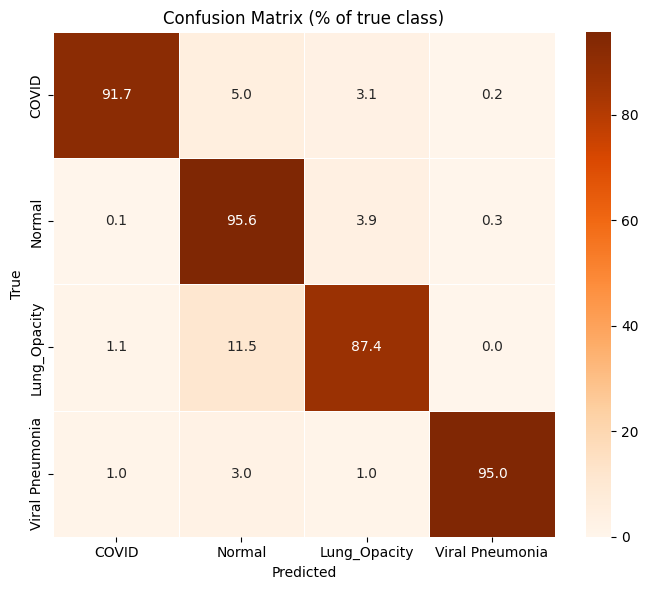

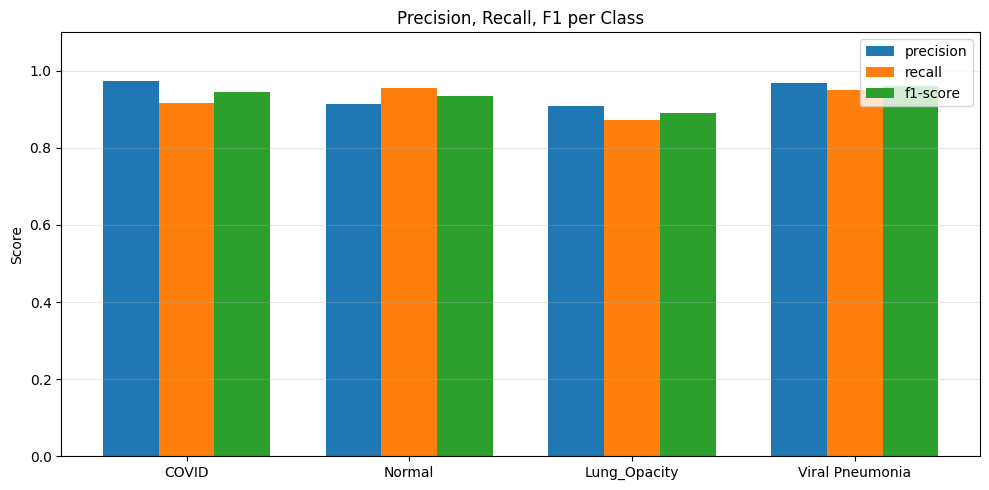

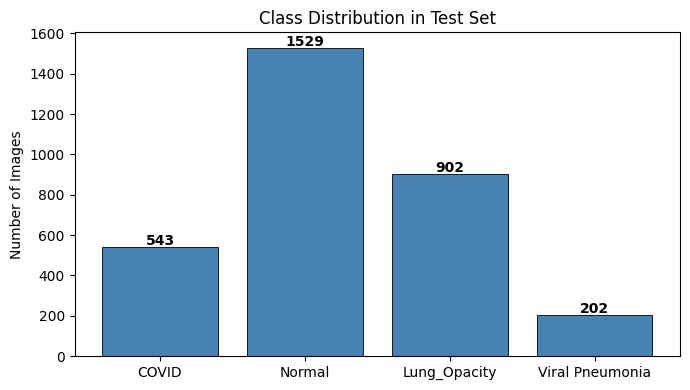

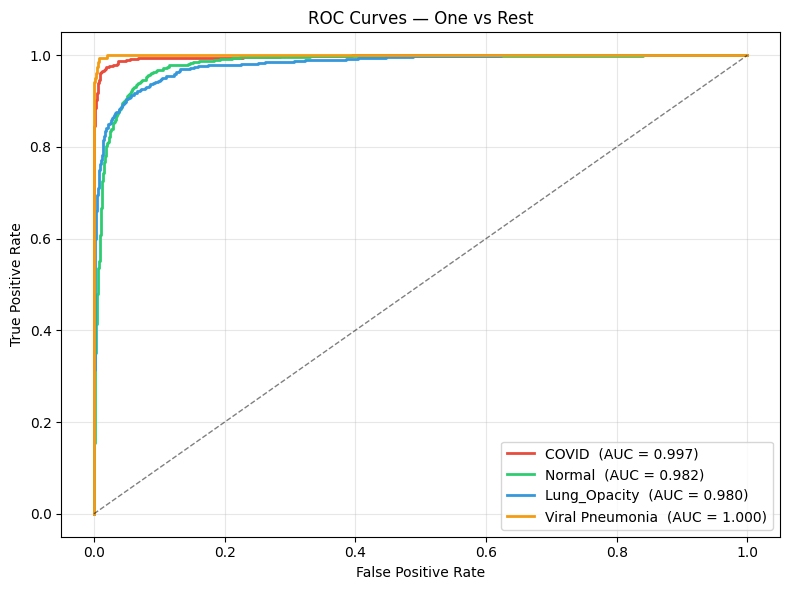

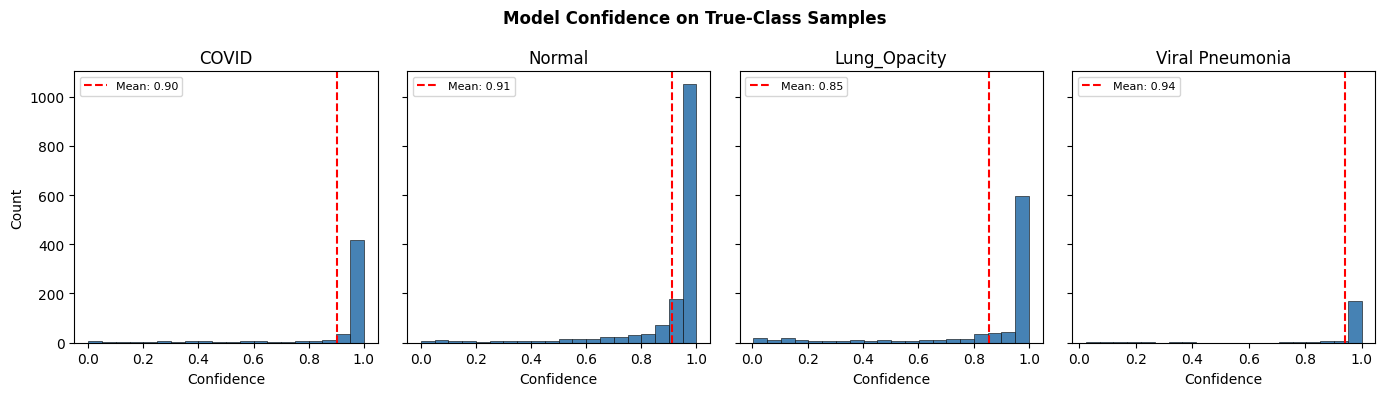

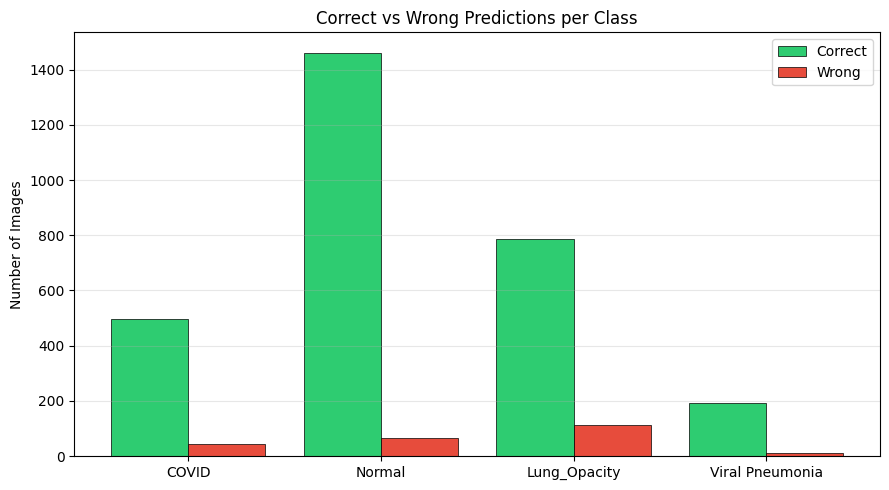

In [10]:
model.eval()

# Collect all test predictions and probabilities
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        out  = model(imgs)
        probs = F.softmax(out, dim=1)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)


# ---- Plot 1: Training Loss and Accuracy Curves ----------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs, history['train_loss'], label='Train Loss')
ax1.plot(epochs, history['val_loss'],   label='Val Loss')
ax1.set_title('Loss Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history['train_acc'], label='Train Acc')
ax2.plot(epochs, history['val_acc'],   label='Val Acc')
ax2.set_title('Accuracy Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graph_training_curves.png', dpi=150)
plt.show()


# ---- Plot 2: Confusion Matrix (raw counts) --------------------
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix (counts)')
plt.tight_layout()
plt.savefig('graph_confusion_matrix_counts.png', dpi=150)
plt.show()


# ---- Plot 3: Confusion Matrix (normalised %) ------------------
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix (% of true class)')
plt.tight_layout()
plt.savefig('graph_confusion_matrix_pct.png', dpi=150)
plt.show()


# ---- Plot 4: Per-class Precision, Recall, F1 ------------------
report = classification_report(all_labels, all_preds,
                                target_names=CLASS_NAMES, output_dict=True)

metrics     = ['precision', 'recall', 'f1-score']
x           = np.arange(len(CLASS_NAMES))
bar_width   = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, metric in enumerate(metrics):
    values = [report[cls][metric] for cls in CLASS_NAMES]
    ax.bar(x + i * bar_width, values, width=bar_width, label=metric)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0, 1.1)
ax.set_title('Precision, Recall, F1 per Class')
ax.set_ylabel('Score')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graph_per_class_metrics.png', dpi=150)
plt.show()


# ---- Plot 5: Class Distribution in Test Set -------------------
class_counts = np.bincount(all_labels)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(CLASS_NAMES, class_counts, color='steelblue', edgecolor='black', linewidth=0.6)
ax.set_title('Class Distribution in Test Set')
ax.set_ylabel('Number of Images')
for i, v in enumerate(class_counts):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('graph_class_distribution.png', dpi=150)
plt.show()


# ---- Plot 6: ROC Curves (one-vs-rest per class) ---------------
labels_bin = label_binarize(all_labels, classes=range(len(CLASS_NAMES)))

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12']

for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{cls}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — One vs Rest')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graph_roc_curves.png', dpi=150)
plt.show()


# ---- Plot 7: Prediction Confidence Distribution ---------------
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(14, 4), sharey=True)

for i, (cls, ax) in enumerate(zip(CLASS_NAMES, axes)):
    
    mask = all_labels == i
    confidence = all_probs[mask, i]
    ax.hist(confidence, bins=20, color='steelblue', edgecolor='black', linewidth=0.4)
    ax.set_title(cls)
    ax.set_xlabel('Confidence')
    if i == 0:
        ax.set_ylabel('Count')
    ax.axvline(confidence.mean(), color='red', linestyle='--',
               label=f'Mean: {confidence.mean():.2f}')
    ax.legend(fontsize=8)

plt.suptitle('Model Confidence on True-Class Samples', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('graph_confidence_distribution.png', dpi=150)
plt.show()


# ---- Plot 8: Correct vs Wrong predictions per class -----------
correct_per_class = np.zeros(len(CLASS_NAMES))
wrong_per_class   = np.zeros(len(CLASS_NAMES))

for true, pred in zip(all_labels, all_preds):
    if true == pred:
        correct_per_class[true] += 1
    else:
        wrong_per_class[true]   += 1

x         = np.arange(len(CLASS_NAMES))
bar_width  = 0.4

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - bar_width/2, correct_per_class, width=bar_width, label='Correct', color='#2ECC71', edgecolor='black', linewidth=0.5)
ax.bar(x + bar_width/2, wrong_per_class,   width=bar_width, label='Wrong',   color='#E74C3C', edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_title('Correct vs Wrong Predictions per Class')
ax.set_ylabel('Number of Images')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graph_correct_vs_wrong.png', dpi=150)
plt.show()

In [35]:
url = "https://prod-images-static.radiopaedia.org/images/52197347/a36d7944927e369c90035d4fcbb7af_big_gallery.jpeg"

# Download image
response = requests.get(url)

# Open as PIL image
img_pil = Image.open(BytesIO(response.content))

# (Optional but recommended for X-rays)
img_pil = img_pil.convert('L')   # grayscale

# Save as PNG
img_pil.save("xray.png")
print("Saved as xray.png")

Saved as xray.png


File       : xray.png
Prediction : COVID
Confidence : 99.91%

  COVID                 99.9%  #######################################
  Normal                 0.1%  
  Lung_Opacity           0.0%  
  Viral Pneumonia        0.0%  


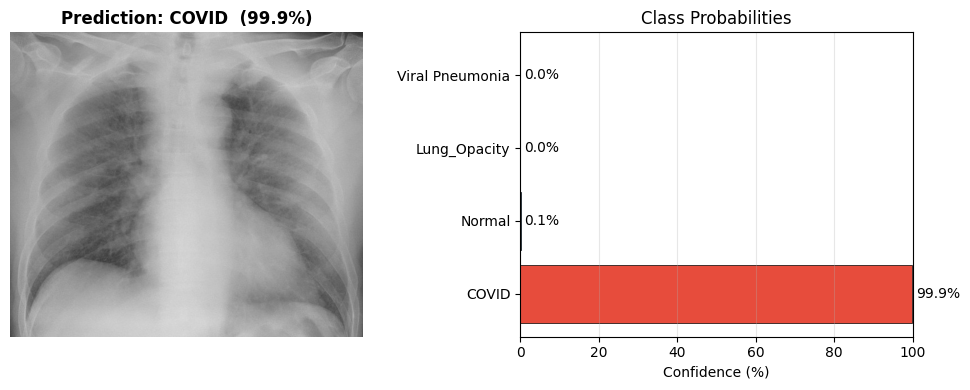

In [36]:

IMAGE_PATH = 'xray.png'
predict_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Load and classify
img_pil = Image.open(IMAGE_PATH).convert('RGB')
img_t   = predict_transform(img_pil).unsqueeze(0).to(DEVICE)

model.eval()
with torch.no_grad():
    out   = model(img_t)
    probs = F.softmax(out, dim=1).squeeze(0).cpu().numpy()

pred_idx   = probs.argmax()
pred_label = CLASS_NAMES[pred_idx]
confidence = probs[pred_idx]

# Print result
print(f'File       : {Path(IMAGE_PATH).name}')
print(f'Prediction : {pred_label}')
print(f'Confidence : {confidence*100:.2f}%')
print()
for cls, prob in zip(CLASS_NAMES, probs):
    bar = '#' * int(prob * 40)
    print(f'  {cls:<20} {prob*100:5.1f}%  {bar}')

# Plot image + probability bar chart
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(10, 4))

ax_img.imshow(img_pil, cmap='gray')
ax_img.axis('off')
ax_img.set_title(f'Prediction: {pred_label}  ({confidence*100:.1f}%)',
                 fontsize=12, fontweight='bold')

colors = ['#E74C3C' if cls == pred_label else 'steelblue' for cls in CLASS_NAMES]
ax_bar.barh(CLASS_NAMES, probs * 100, color=colors, edgecolor='black', linewidth=0.5)
ax_bar.set_xlim(0, 100)
ax_bar.set_xlabel('Confidence (%)')
ax_bar.set_title('Class Probabilities')
ax_bar.grid(True, axis='x', alpha=0.3)
for j, prob in enumerate(probs):
    ax_bar.text(prob * 100 + 1, j, f'{prob*100:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('single_prediction.png', dpi=150)
plt.show()